# lmax Convergence Test (full-resolution forward model)

Compare MARS (2-beam) mapmaking at lmax = 40, 60, 90, 179,
with the forward model always run at lmax_sim = 179 (full resolution).
The mapmaking A-matrix uses the reduced lmax, but the simulated data
contains sky power up to lmax_sim. This tests whether reduced-lmax
mapmaking recovers ell < 20 modes accurately even when small-scale
sky structure is present in the data.

In [1]:
from pathlib import Path

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

In [2]:
results_dir = Path("results")

runs = ["mars-lmax40", "mars-lmax60", "mars-lmax90", "mars-lmax179"]
lmax_vals = [40, 60, 90, 179]
labels = [f"lmax={l}" for l in lmax_vals]

data = {}
for run, lm in zip(runs, lmax_vals):
    d = np.load(results_dir / f"{run}.npz")
    data[lm] = d
    lmax_sim = int(d["lmax_sim"]) if "lmax_sim" in d else "N/A"
    print(f"  {run}: lmax={int(d['lmax'])}, lmax_sim={lmax_sim}, "
          f"nvec={int(d['nvec'])}, k={len(d['Sigma'])}")

  mars-lmax40: lmax=40, lmax_sim=179, nvec=130, k=800
  mars-lmax60: lmax=60, lmax_sim=179, nvec=182, k=800
  mars-lmax90: lmax=90, lmax_sim=179, nvec=258, k=800
  mars-lmax179: lmax=179, lmax_sim=179, nvec=478, k=800


## Alm comparison for ell <= 20

The reference is lmax=179. For each lower-lmax run, compare the
recovered alm coefficients at ell <= 20 against the reference.
Both x_rec arrays are in healpy ordering, so `hp.alm2cl` gives
the per-ell power. We compare the cross-correlation coefficient.

In [3]:
# Truncate all recovered alm to a common lmax for comparison.
# healpy alm arrays have different lengths for different lmax,
# so we filter to ell <= compare_lmax using hp.almxfl.

compare_lmax = 20
ref_lmax = 179

# Reference: lmax=179 run, filtered to ell <= compare_lmax
x_ref = data[ref_lmax]["x_rec"]
x_true_ref = data[ref_lmax]["x_true"]
fl_ref = np.zeros(ref_lmax + 1)
fl_ref[:compare_lmax + 1] = 1.0
x_ref_filt = hp.almxfl(x_ref, fl_ref)
x_true_filt = hp.almxfl(x_true_ref, fl_ref)

cl_ref = hp.alm2cl(x_ref_filt)[:compare_lmax + 1]
cl_true = hp.alm2cl(x_true_filt)[:compare_lmax + 1]

## Power spectrum comparison (ell <= 20)

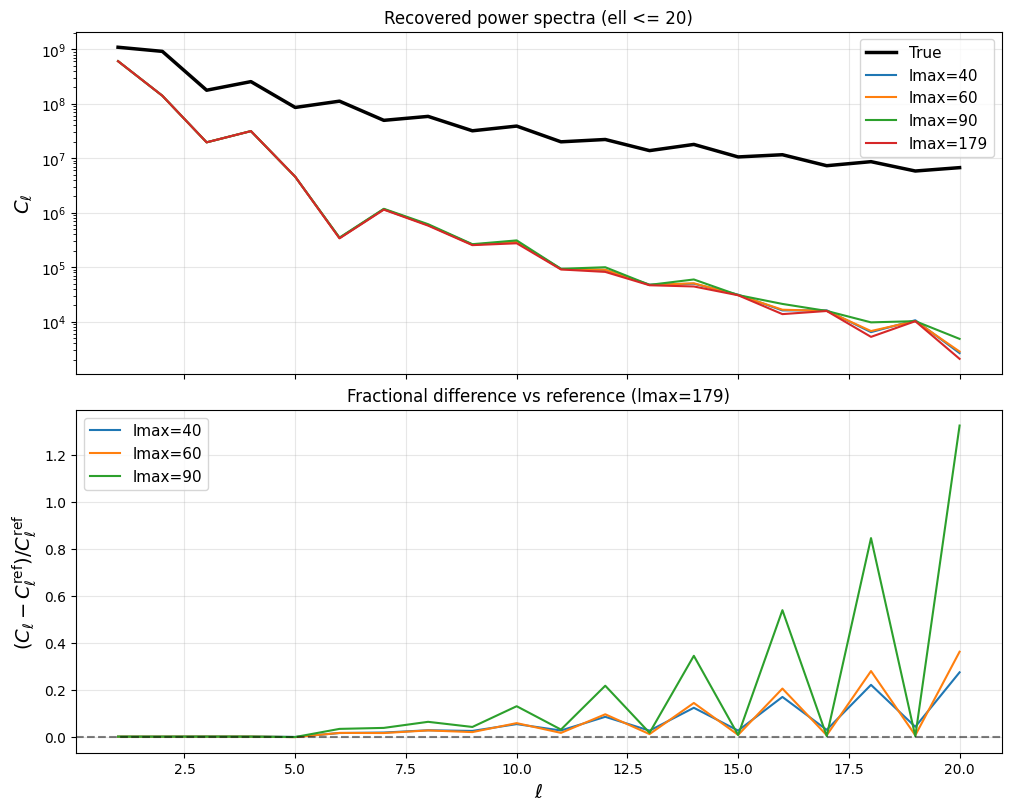

In [4]:
ell = np.arange(compare_lmax + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True,
                         sharex=True)

# Top: Cl comparison
ax = axes[0]
ax.semilogy(ell[1:], cl_true[1:], "k-", lw=2.5, label="True")
for lm in lmax_vals:
    x_rec = data[lm]["x_rec"]
    lm_actual = int(data[lm]["lmax"])
    fl = np.zeros(lm_actual + 1)
    fl[:compare_lmax + 1] = 1.0
    x_filt = hp.almxfl(x_rec, fl)
    cl = hp.alm2cl(x_filt)[:compare_lmax + 1]
    ax.semilogy(ell[1:], cl[1:], lw=1.5, label=f"lmax={lm}")
ax.set_ylabel(r"$C_\ell$", fontsize=14)
ax.set_title(f"Recovered power spectra (ell <= {compare_lmax})")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Bottom: fractional difference from reference (lmax=179)
ax = axes[1]
for lm in lmax_vals[:-1]:  # skip reference itself
    x_rec = data[lm]["x_rec"]
    lm_actual = int(data[lm]["lmax"])
    fl = np.zeros(lm_actual + 1)
    fl[:compare_lmax + 1] = 1.0
    x_filt = hp.almxfl(x_rec, fl)
    cl = hp.alm2cl(x_filt)[:compare_lmax + 1]
    frac = np.zeros_like(cl)
    valid = cl_ref > 0
    frac[valid] = (cl[valid] - cl_ref[valid]) / cl_ref[valid]
    ax.plot(ell[1:], frac[1:], lw=1.5, label=f"lmax={lm}")
ax.axhline(0, color="k", ls="--", alpha=0.5)
ax.set_xlabel(r"$\ell$", fontsize=14)
ax.set_ylabel(r"$(C_\ell - C_\ell^{\rm ref}) / C_\ell^{\rm ref}$",
              fontsize=14)
ax.set_title(f"Fractional difference vs reference (lmax=179)")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.show()

## Transfer functions (ell <= 20)

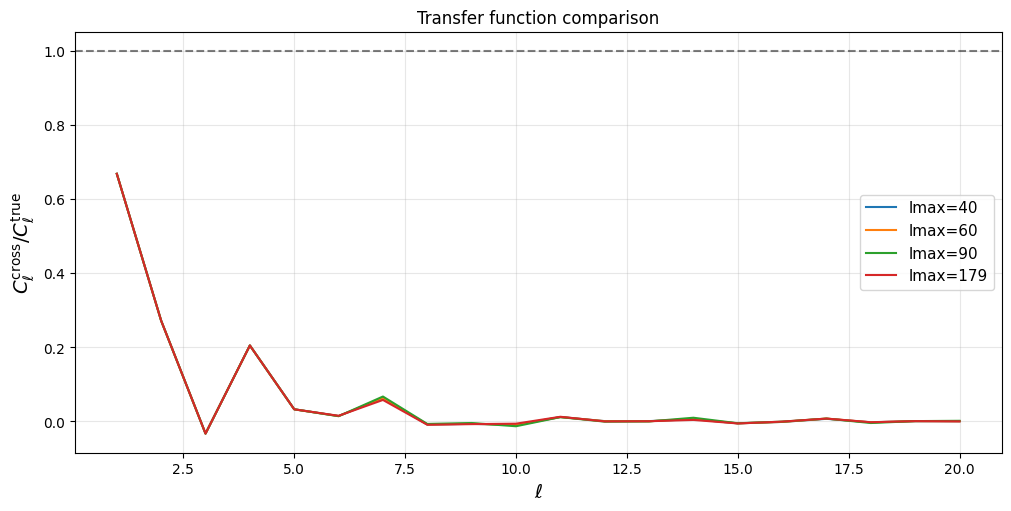

In [5]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
for lm in lmax_vals:
    x_rec = data[lm]["x_rec"]
    x_true = data[lm]["x_true"]
    lm_actual = int(data[lm]["lmax"])
    fl = np.zeros(lm_actual + 1)
    fl[:compare_lmax + 1] = 1.0
    cl_cross = hp.alm2cl(hp.almxfl(x_true, fl),
                         hp.almxfl(x_rec, fl))[:compare_lmax + 1]
    cl_auto = hp.alm2cl(hp.almxfl(x_true, fl))[:compare_lmax + 1]
    tf = np.zeros_like(cl_auto)
    valid = cl_auto > 0
    tf[valid] = cl_cross[valid] / cl_auto[valid]
    ax.plot(ell[1:], tf[1:], lw=1.5, label=f"lmax={lm}")
ax.axhline(1, color="k", ls="--", alpha=0.5)
ax.set_xlabel(r"$\ell$", fontsize=14)
ax.set_ylabel(r"$C_\ell^{\rm cross} / C_\ell^{\rm true}$", fontsize=14)
ax.set_title("Transfer function comparison")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.show()

## Cumulative residual RMS vs ell

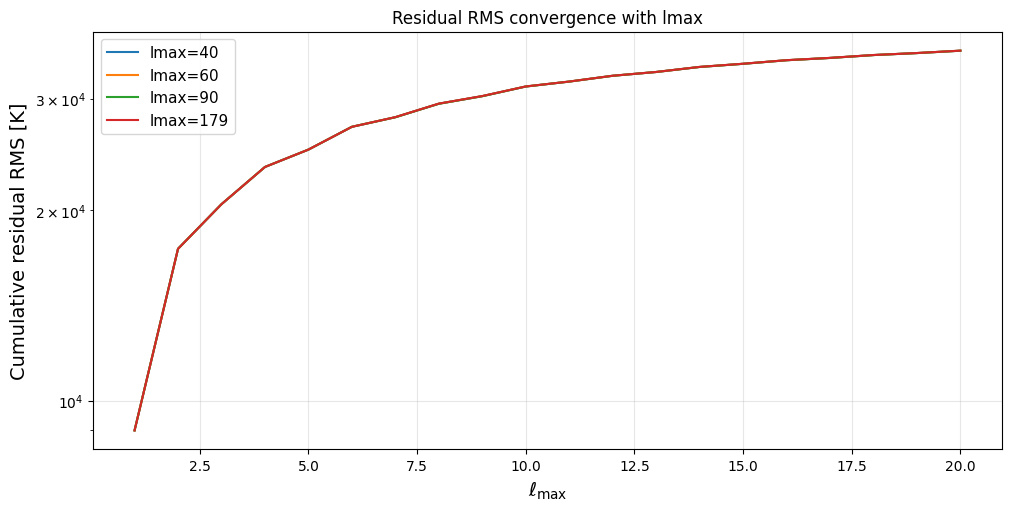

In [6]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
for lm in lmax_vals:
    x_rec = data[lm]["x_rec"]
    x_true = data[lm]["x_true"]
    lm_actual = int(data[lm]["lmax"])
    fl = np.zeros(lm_actual + 1)
    fl[:compare_lmax + 1] = 1.0
    res = hp.almxfl(x_rec, fl) - hp.almxfl(x_true, fl)
    cl_res = hp.alm2cl(res)[:compare_lmax + 1]
    ell_arr = np.arange(compare_lmax + 1)
    weights = (2 * ell_arr + 1) / (4 * np.pi)
    rms_cum = np.sqrt(np.cumsum(weights * cl_res))
    ax.semilogy(ell_arr[1:], rms_cum[1:], lw=1.5, label=f"lmax={lm}")
ax.set_xlabel(r"$\ell_{\rm max}$", fontsize=14)
ax.set_ylabel("Cumulative residual RMS [K]", fontsize=14)
ax.set_title("Residual RMS convergence with lmax")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.show()

## Fractional Residual Power vs ell

$C_\ell^{\rm res} / C_\ell^{\rm true}$ — 0 = perfect, 1 = no constraint.

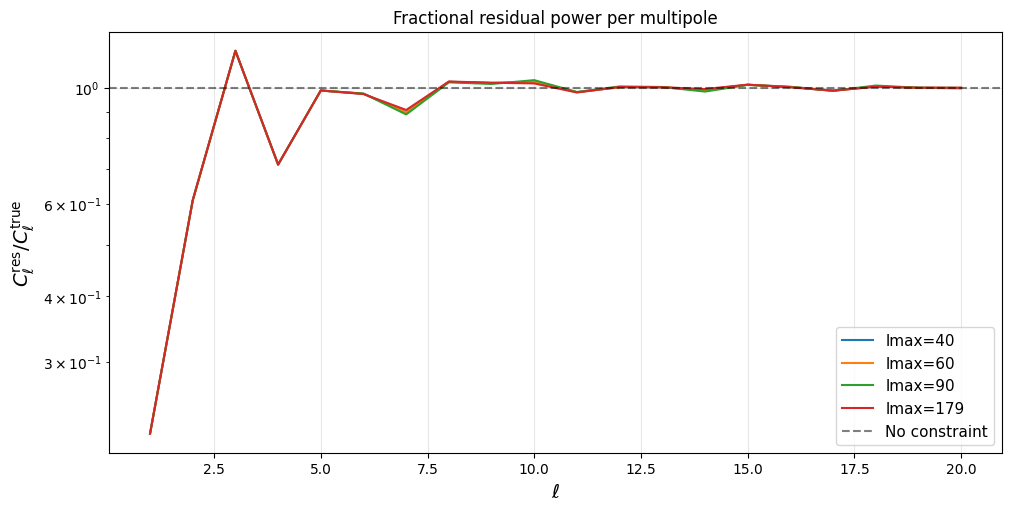

In [7]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
for lm in lmax_vals:
    x_rec = data[lm]["x_rec"]
    x_true = data[lm]["x_true"]
    lm_actual = int(data[lm]["lmax"])
    fl = np.zeros(lm_actual + 1)
    fl[:compare_lmax + 1] = 1.0
    cl_true_f = hp.alm2cl(hp.almxfl(x_true, fl))[:compare_lmax + 1]
    cl_res = hp.alm2cl(
        hp.almxfl(x_rec, fl) - hp.almxfl(x_true, fl)
    )[:compare_lmax + 1]
    frac = np.zeros_like(cl_true_f)
    valid = cl_true_f > 0
    frac[valid] = cl_res[valid] / cl_true_f[valid]
    ell_arr = np.arange(compare_lmax + 1)
    ax.semilogy(ell_arr[1:], frac[1:], lw=1.5, label=f"lmax={lm}")
ax.axhline(1, color="k", ls="--", alpha=0.5, label="No constraint")
ax.set_xlabel(r"$\ell$", fontsize=14)
ax.set_ylabel(r"$C_\ell^{\rm res} / C_\ell^{\rm true}$", fontsize=14)
ax.set_title("Fractional residual power per multipole")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.show()

## Map comparison (ell <= 10)

Visual check: do the maps look the same at the largest scales?

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


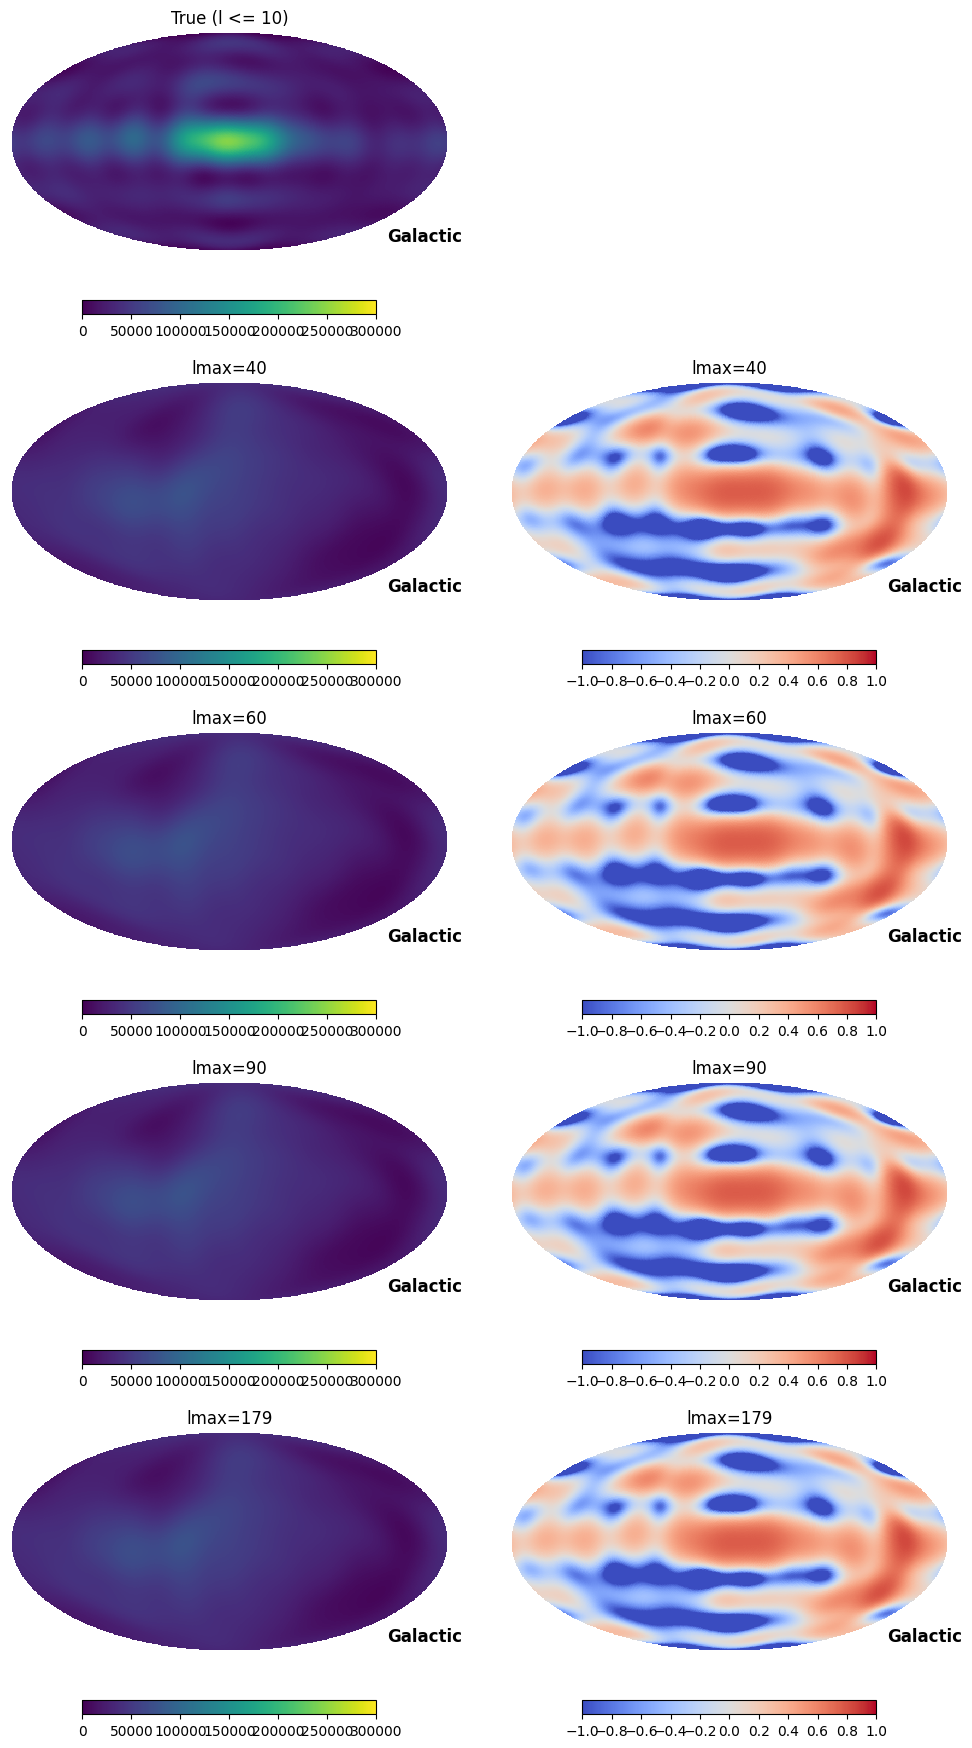

In [8]:
import mistsim.plotting as msplt

x_recs = []
for lm in lmax_vals:
    x_rec = data[lm]["x_rec"]
    lm_actual = int(data[lm]["lmax"])
    # Pad shorter alm arrays to match reference lmax for healpy
    if lm_actual < ref_lmax:
        n_ref = hp.Alm.getsize(ref_lmax)
        x_padded = np.zeros(n_ref, dtype=x_rec.dtype)
        n_short = hp.Alm.getsize(lm_actual)
        # Copy matching (ell, m) indices
        for ell in range(lm_actual + 1):
            for m in range(ell + 1):
                idx_short = hp.Alm.getidx(lm_actual, ell, m)
                idx_long = hp.Alm.getidx(ref_lmax, ell, m)
                x_padded[idx_long] = x_rec[idx_short]
        x_recs.append(x_padded)
    else:
        x_recs.append(x_rec)

x_true_full = data[ref_lmax]["x_true"]

fig = msplt.plot_comparison_grid(
    x_true_full, x_recs, labels, ref_lmax, plot_lmax=10,
    nside=128, plot_galactic=True, frac_range=1.0,
    ratio=True, orientation="vertical",
)
plt.show()

## Residual maps vs reference (lmax=179)

Absolute difference (in K) between each reduced-lmax recovery and the
lmax=179 recovery, evaluated at ell <= 10. Top row is the reference map.

In [9]:
%matplotlib widget

In [16]:
plt.close("all")

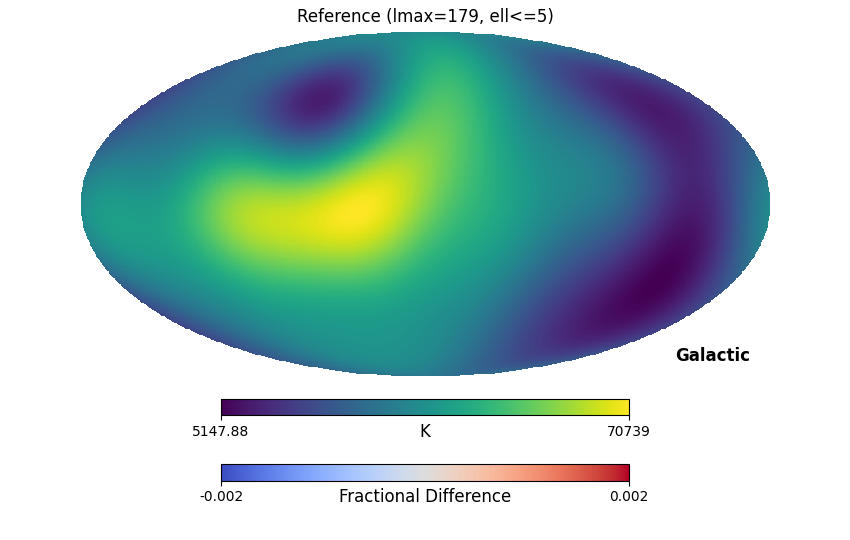

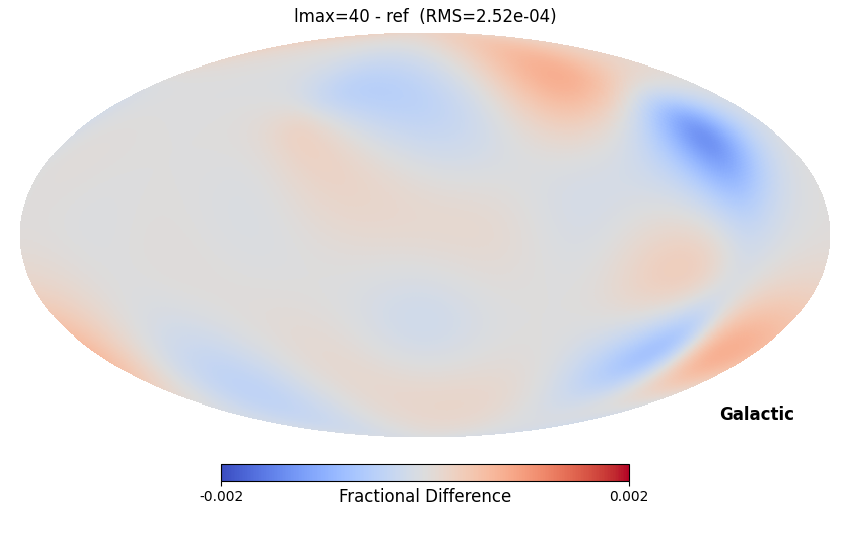

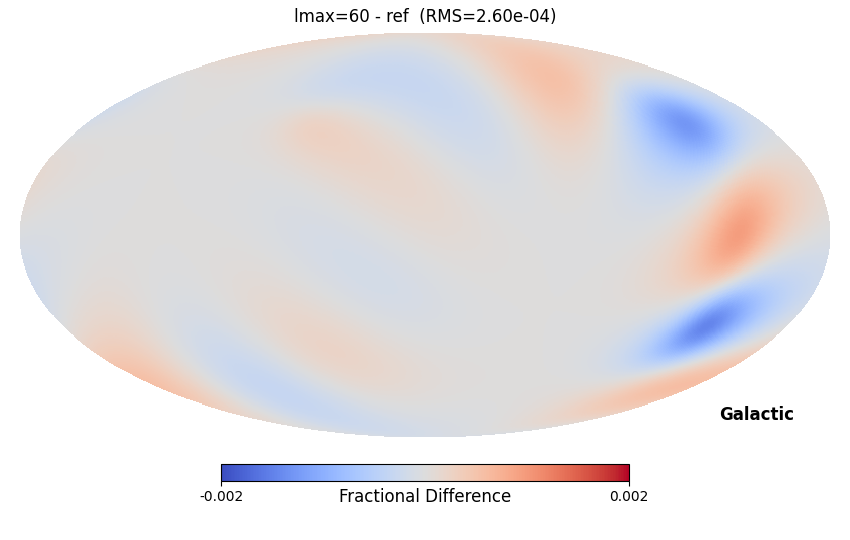

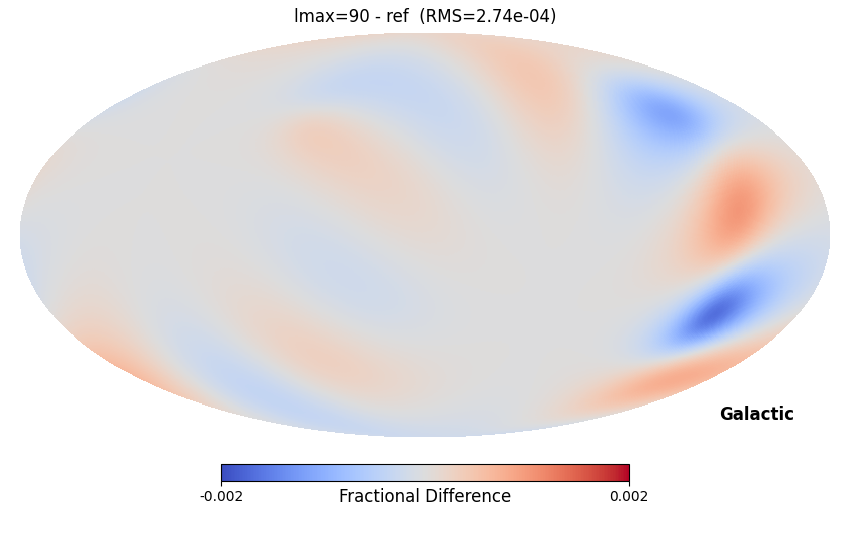

In [18]:
nside = 128
plot_lmax = 5

# Reference map (lmax=179 recovery, filtered to ell <= plot_lmax)
fl_plot = np.zeros(ref_lmax + 1)
fl_plot[:plot_lmax + 1] = 1.0
ref_map = hp.alm2map(hp.almxfl(x_recs[-1], fl_plot), nside)

test_lmax_vals = lmax_vals[:-1]  # 40, 60, 90
nrows = 1 + len(test_lmax_vals)


# Row 0: reference map
rot = (0, 0, 0) if not True else (180, 0, 0)  # galactic center
hp.mollview(ref_map, title=f"Reference (lmax=179, ell<={plot_lmax})",
            unit="K", hold=True, fig=fig, sub=(nrows, 1, 1),
            coord=["C", "G"])
plt.show()

# Rows 1-3: absolute residuals
for i, lm in enumerate(test_lmax_vals):
    test_map = hp.alm2map(hp.almxfl(x_recs[i], fl_plot), nside)
    res_map = test_map - ref_map
    res_map /= ref_map
    rms = np.std(res_map)
    hp.mollview(res_map, title=f"lmax={lm} - ref  (RMS={rms:.2e})", cmap="coolwarm",
                unit="Fractional Difference", coord=["C", "G"], min=-0.002, max=0.002)

    plt.show()

In [11]:
(hp.Alm.getsize(90)*2 - 91) / 32400

0.25558641975308644

## SVD budget usage

Check whether any of the reduced-lmax runs are still truncation-limited.

In [12]:
for lm in lmax_vals:
    d = data[lm]
    Sigma = d["Sigma"]
    nvec = int(d["nvec"])
    k = len(Sigma)
    nalm = (int(d["lmax"]) + 1) ** 2
    flag = " ** TRUNCATED **" if nvec == k else ""
    print(f"  lmax={lm:>3d}: nalm={nalm:>6d}, k={k}, nvec={nvec}, "
          f"Sigma[-1]={Sigma[-1]:.2e}{flag}")

  lmax= 40: nalm=  1681, k=800, nvec=130, Sigma[-1]=4.72e-11
  lmax= 60: nalm=  3721, k=800, nvec=182, Sigma[-1]=4.72e-11
  lmax= 90: nalm=  8281, k=800, nvec=258, Sigma[-1]=4.72e-11
  lmax=179: nalm= 32400, k=800, nvec=478, Sigma[-1]=4.72e-11
